## Análisis del corpus.

En este cuaderno se realiza un estudio sobre las propiedades, características y otros datos de interés que podemos obtener del Corpus Completo.

Todas las funciones utilizadas para realizar la mayoría de los cálculos y gráficos este apartado se encuentran en este [script de python](funciones_estadisticos.py).

In [1]:
import pandas as pd
from funciones_estadisticos import *

Primero separamos nuestros archivos JSON del Corpus Completo en dos (hilos y comentarios) para poder sacar estadísticas separadas para cada tipo de entrada.

In [2]:
book_submissions, book_comments = separar_dataframes('completo_books.json')
jobs_submissions, jobs_comments = separar_dataframes('completo_jobs.json')
lol_submissions, lol_comments = separar_dataframes('completo_LeagueOfLegends.json')
random_submissions, random_comments = separar_dataframes('completo_RandomThoughts.json')
travel_submissions, travel_comments = separar_dataframes('completo_travel.json')
unpopular_submissions, unpopular_comments = separar_dataframes('completo_unpopularopinion.json')

lista_dataframes = [book_submissions, book_comments, jobs_submissions, jobs_comments, lol_submissions, lol_comments,
					random_submissions, random_comments, travel_submissions, travel_comments, unpopular_submissions, unpopular_comments]

lista_dataframes_comentarios = [book_comments, jobs_comments, lol_comments, random_comments, travel_comments, unpopular_comments]

display(book_submissions.head())
display(book_comments.head())

,author,created_utc,id,name,num_comments,score,selftext,subreddit,title,created_datetime,id_hilo_limpio
0,kimmisy,1.742420e+09,1jf8hdb,t3_1jf8hdb,255,675,I’m so tired of seeing this ending. In the boo...,books,I’m sick of badass FMC having a « happy ending...,2025-03-19T21:34:03+00:00,0
1,lydocia,1.738822e+09,1iivxkz,t3_1iivxkz,350,124,"Way back when, the books I used to read all ha...",books,When did authors stop giving chapters individu...,2025-02-06T06:07:23+00:00,1
2,sofbunny,1.739574e+09,1ipnh8i,t3_1ipnh8i,1476,5842,"To be more specific, chapters 19 and 21, when ...",books,We were assigned The Grapes of Wrath in high s...,2025-02-14T22:57:49+00:00,2
3,Raj_Valiant3011,1.736711e+09,1hzv1nf,t3_1hzv1nf,190,55,"I was recently reading Fyodor Dostoevsky's, Cr...",books,What are some books who have an unreliable nar...,2025-01-12T19:44:44+00:00,3
4,tambitoast,1.742316e+09,1je9imj,t3_1je9imj,948,309,I was wondering if there has ever been any rea...,books,What's the pettiest reason you've been mad at ...,2025-03-18T16:46:46+00:00,4


,author,body,controversiality,created_utc,id,link_id,parent_id,score,subreddit,created_datetime
0,kimmisy,"Thanks! I’ve heard of that before, I’ll defini...",0,1.742420e+09,miox56e,t3_1jf8hdb,t1_miowxfi,1,books,2025-03-19T21:41:27+00:00
1,IAmThePonch,Check out mistborn then op,1,1.742420e+09,miowxfi,t3_1jf8hdb,t3_1jf8hdb,2,books,2025-03-19T21:40:23+00:00
2,kimmisy,"Very curious, what books would you recommend? ...",0,1.742420e+09,miowzgo,t3_1jf8hdb,t1_miowqqg,23,books,2025-03-19T21:40:39+00:00
3,zaccus,If a man settles down and has a family does th...,0,1.742421e+09,miox9sw,t3_1jf8hdb,t3_1jf8hdb,24,books,2025-03-19T21:42:08+00:00
4,sabla,That's why I loved Tamora Pierce's Tortall ser...,0,1.742421e+09,mioydfb,t3_1jf8hdb,t3_1jf8hdb,350,books,2025-03-19T21:47:43+00:00


Aunque ya hemos visto que hay una dispersión temporal suficiente en el corpus, no hemos visto cómo se distribuyen estos hilos y comentarios a lo largo de este tiempo. Para ello realizamos un par de histogramas por subreddit.

In [3]:
histograma(lista_dataframes)

A simple vista, estos gráficos no parecen tener una apariencia normal de histograma pues hay demasiadas coincidencias en la altura de estas barras. Esto es la consecuencia de la forma en la que hemos realizado la extracción, ya que al extraer un máximo de un hilo por día, y veinte comentarios (tras la unificación), la altura de estas barras prácticamente en todos los casos va a ser un múltiplo de estos números. Observamos, en cambio, que se generan algunas excepciones en los comentarios de **r/jobs** y **r/LeagueOfLegends** debidos a la aleatoriedad introducida en el muestreo realizado en la unificación, lo que produce que si alguno de los primeros 30 comentarios iniciales del hilo (que suelen ser del mismo día o muy similar) era de una fecha con diferencia una notable y ha sido escogido, produzca estas pequeñas "interferencias" en el gráfico.

Antes de empezar a calcular métricas basadas en el texto de los comentarios, vamos a descubrir la distribución de idiomas de nuestro corpus, algo que siempre es interesante.

In [ ]:
from langdetect import detect
import re

diccionario_idiomas = {
	'en': 'Inglés',
	'es': 'Español',
	'fr': 'Francés',
	'de': 'Alemán',
	'it': 'Italiano'
}
def deteccion_segura(texto):
	if not texto or not re.search('[a-zA-Z]', str(texto)):
		return 'unknown'
	
	try:
		return detect(texto)
	except:
		return 'unknown'

for df in lista_dataframes:
	if 'body' in df.columns:
		df['language_code'] = df['body'].apply(deteccion_segura)
		df['language'] = df['language_code'].apply(lambda x: diccionario_idiomas.get(x, 'Otro') if isinstance(x, str) and len(x) > 0 else 'unknown')
	else:
		df['language_code'] = df['title'].apply(deteccion_segura)
		df['language'] = df['language_code'].apply(lambda x: diccionario_idiomas.get(x, 'Otro') if isinstance(x, str) and len(x) > 0 else 'unknown')

plot_pie(lista_dataframes, columna='language', titulo='Distribucion de Idiomas en el Corpus')

<Figure size 800x800 with 0 Axes>

Como era de imaginar, la gran mayoría del corpus se encuentra documentado en Inglés, con tanto como un $96.5\%$ por lo que podríamos permitirnos discriminar el resto de idiomas a la hora de calcular las *stopwords* necesarias en otras tareas. Pero en la limpieza detallada se intentará ser específico con este tema. 

Procedemos entonces a calcular varias métricas básicas de los comentarios del corpus como son el número de palabras, tokens, frases, medias de estos datos y el *TTR* (o Riqueza Léxica), que se calcula dividiendo el número de palabras entre el número de tokens.

Hemos decidido no incluir las publicaciones de los hilos para calcular estas métricas porque la información relevante para el análisis de comportamiento de cada hilo reside en su gran mayoría en sus comentarios, mientras que la publicación original meramente sienta unas bases para el discurso.

In [4]:
lista_dataframes_metricas = metricas_a_df(lista_dataframes_comentarios, 'body')

metricas_generales = calcular_estadisticos_corpus(lista_dataframes_metricas)

Calculando métricas para 1180 filas de r/books...
Calculando métricas para 1180 filas de r/jobs...
Calculando métricas para 1180 filas de r/leagueoflegends...
Calculando métricas para 1180 filas de r/RandomThoughts...
Calculando métricas para 1180 filas de r/travel...
Calculando métricas para 1180 filas de r/unpopularopinion...
✅ ¡Todas las métricas calculadas!


In [5]:
display(metricas_generales)

,Subreddit,Comentarios,Total Palabras,Total Tokens,Total Frases,Media Palabras/Coment.,Media Frases/Coment.,Media Palabras/Frase,Riqueza Léxica Media (TTR %)
0,r/books,1180,34731,51704,3203,29.43,2.71,13.71,87.49
1,r/jobs,1180,32398,47713,3211,27.46,2.72,12.45,88.98
2,r/travel,1180,32278,47460,3148,27.35,2.67,12.49,88.66
3,r/unpopularopinion,1180,28480,41101,2668,24.14,2.26,13.03,89.66
4,r/leagueoflegends,1180,26960,36742,2239,22.85,1.90,14.31,91.35
5,r/RandomThoughts,1180,18512,25690,2013,15.69,1.71,10.60,92.53


Ahora podemos visualizar dichas métricas básicas mediante gráficos de caja y bigotes, que nos darán una perspectiva sobre cómo se distribuye cada subreddit para cada una de estas 5 métricas: Palabras, Tokens, Frases, Palabras por Frase y TTR.

In [6]:
metricas = ['palabras','tokens','frases','palabras_por_frase','ttr']
for i in range(len(metricas)):
	boxplot(lista_dataframes_metricas, metrica=metricas[i])

Con estas representaciones podemos concluir que por lo general, el corpus seleccionado tiene una distribución bastante similar a lo largo de los 6 subreddits seleccionados.

De todas formas, es interesante cómo en **r/RandomThoughts** el mínimo de Palabras es 0 mientras que el de Tokens es 3, lo lógico sería pensar que si el mínimo de Tokens es 3, el mínimo de Palabras sería como mínimo 1 (suponiendo que los tres Tokens fueran idénticos), pero esto ocurre porque a la hora de calcular el número de Palabras, buscamos cadenas de texto alfanuméricas, en cambio, los tokens cuentan signos de puntuación y símbolos, por lo que es muy probable que se trate de un comentario del estilo "!!!" o ":) :) :)", conteniendo únicamente 3 Tokens idénticos de carácter no alfanumérico.

Sería interesante también ver de qué trata el comentario con menor Riqueza Léxica en el corpus, ya que es un *outlier* bastante notorio, consiguiendo únicamente un $25\%$ de *TTR*, mientras que la media tanto de su subreddit (**r/LeagueOfLegends**) como del corpus en general ronda el $90\%$.

In [7]:
display(lista_dataframes_metricas[2][['body','ttr']].sort_values(by='ttr', ascending=True).head(1))

,body,ttr
1163,peanut zeka peanut zeka peanut zeka peanut zeka,25.0


Descubrimos así que efectivamente este comentario simplemente contiene los nombres de dos jugadores profesionales del videojuego del que trata la comunidad repetidos cuatro veces, de ahí el $25\%$ de *TTR* que obtiene, entendiendo así que se trata de un comentario de asombro por alguna jugada que realizasen o algo similar.

Para terminar la parte de las métricas, podríamos pensar que existe cierta correlación positiva entre el número de Tokens de un comentario y su *Score* (Puntuación), es decir, que a mayor lóngitud del comentario, mayor Puntuación.

Esta hipótesis la podemos comprobar si realizamos un gráfico de puntos comparando los Tokens de cada comentario con su Score.

In [14]:
plot_scatter_longitud_score(lista_dataframes_metricas, columna_longitud='tokens')

Así nos fijamos en que esta hipótesis no es cierta, no existe dicha tal correlación, y es que en general estos comentarios con mayor puntuación no suelen pasar de los 20 o 30 Tokens mientras que los comentarios van desde los 3 Tokens hasta casi los 400. 

Nos gustaría ahora conocer qué temas son los más hablados en estas comunidades. Para ello vamos a realizar una búsqueda y ordenación de las 15 *bigramas* más comúnes en los subreddits.

In [9]:
plot_top_ngramas(lista_dataframes, n=2, top_k=15, columna_texto='body')

Centrándonos únicamente en los 3 bigramas más frecuente de cada comunidad extraemos lo siguiente:

- En **r/books** es común recomendar libros y preguntar sobre libros para leer.
- En **r/jobs** es común conversar sobre el estado del mercado laboral, del pasado reciente y de los nuevos trabajos que surgen (o se consiguen).
- En **r/LeagueOfLegends** es común discutir sobre los cambios introducidos en el juego con la nueva temporada, sobre el final de partida y los equipos enemigos.
- En **r/RandomThoughts** es común conversar sobre el cambio climático, cosas que la gente descubre o se entera recientemente y comentar experiencias de hace años.
- En **r/travel** es común hablar sobre lugares a los que se quiere volver, se va por primera vez o se quiere ir.
- En **r/unpopularopinion** es común hablar sobre asientos de cuero y sopas de tomate y que los comentarios contengan la expresión "My unpopular opinion is..." ("Mi opinion poco popular es...").

Estos resultados parecen ser estándar y no salirse de lo esperado de cada uno de estos subreddits, pero sí que podemos notar el sesgo producido por la extracción y limpieza realizada, pues es lógico pensar que en una comunidad tan amplia como **r/unpopularopinion** los temas más hablados no serían los asientos de cuero o la sopa de tomate.

Podemos realizar ahora nubes de palabras para cada subreddit:

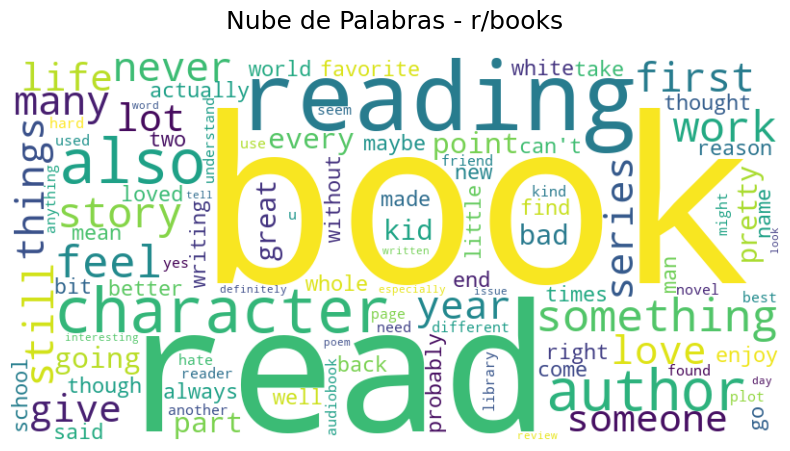

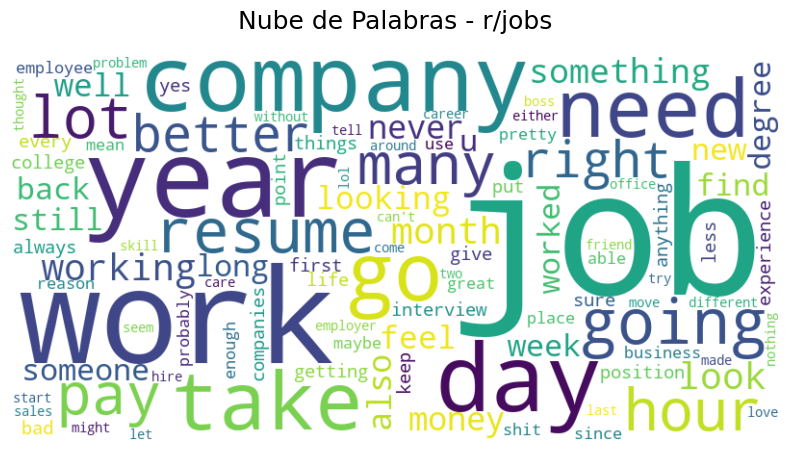

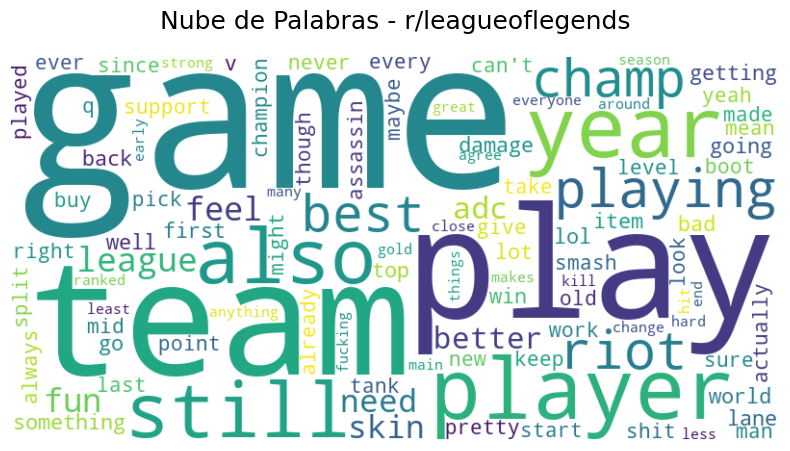

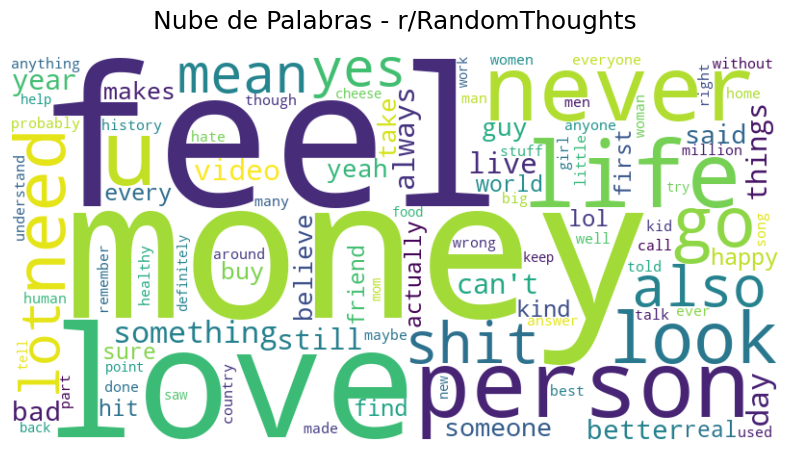

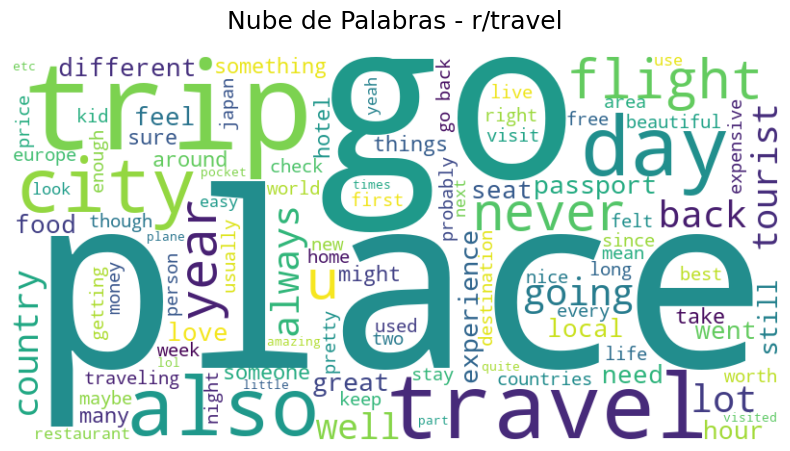

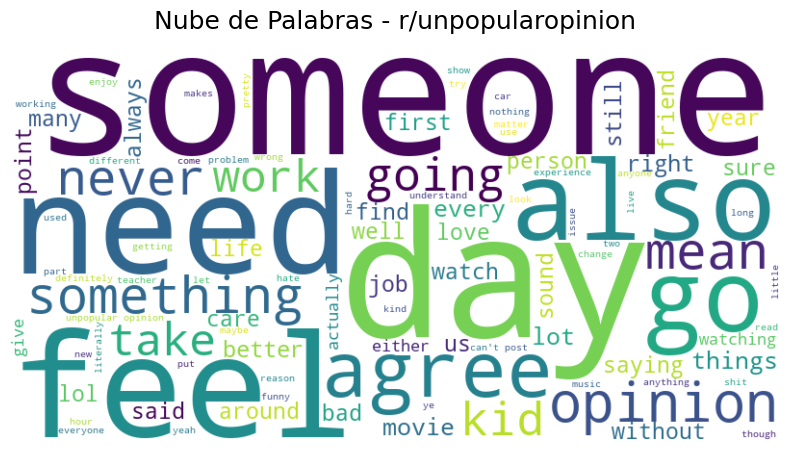

In [10]:
plot_wordclouds(lista_dataframes, columna_texto='body')

Como era de esperar, no difieren mucho las palabras que aparecen como las más usadas con los resultados anteriores de los bigramas más comunes en estas comunidades, pero sí es interesante ver que en **r/RandomThoughts** no aparecen ni la palabra "Climate" ni "Change" como las más usadas "por separado", en cambio aparece "Money" ("Dinero"), que es uno de los temas que aparecen en el gráfico anterior y no es raro pensar que a la gente le interese el tema del dinero.

Por último, vamos a graficar los autores con mayor actividad en nuestro corpus, tanto en hilos como en comentarios.

In [ ]:
barplot(lista_dataframes)

Un resultado interesante de esto es que los autores que suelen crear hilos, no suelen comentar en los suyos propios o en otros del mismo subreddit, pues no ocurre en por lo general que un autor que esté arriba del *ranking* en los hilos, esté en el *ranking* de comentarios (aunque alguno sí que está, como *coffeewalnut05* en **r/travel**).